In [2]:
import phidl
import phidl.geometry as pg
from phidl import quickplot as qp
import numpy as np
import os
from phidl import Device, Path
import phidl.path as pp
from scipy.constants import epsilon_0, mu_0
from scipy.special import ellipk
import phidl.routing as pr

In [3]:
def make_feedline_contact(
        pad_size = 200,
        taper_len = 100,
        feedline_len = 0,
        feedline_width = 66,
        ground_gap = 2,
):

    def make_feedline_sub(pad_size,taper_len,feedline_len,feedline_width):
        pad = pg.taper(length=pad_size,width1=pad_size,width2=pad_size)
        taper = pg.taper(length=taper_len,width1=pad_size,width2=feedline_width)
        feedline = pg.taper(length=feedline_len,width1=feedline_width,width2=feedline_width)

        feedline_dev = phidl.Device("feedline")
        pad_ref1 = feedline_dev.add_ref(pad)
        taper_ref1 = feedline_dev.add_ref(taper)
        feedline_ref = feedline_dev.add_ref(feedline)
        taper_ref1.connect(1,destination=pad_ref1.ports[2])
        feedline_ref.connect(1,destination=taper_ref1.ports[2])
        feedline_dev.xmax = 0
        return feedline_dev
    
    feedline1 = make_feedline_sub(pad_size,taper_len,feedline_len,feedline_width)
    pad_size += 100
    feedline_width += 2*ground_gap
    feedline2 = make_feedline_sub(pad_size,taper_len,feedline_len,feedline_width)

    feedline_outline = pg.boolean(feedline2,feedline1,operation='A-B')
    feedline_outline.xmax = 0
    feedline_outline.add_port(
        'feedline',
        midpoint = (0,0),
        width = 1,
        orientation=0
    )
    feedline_outline.x = 0

    return feedline_outline

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


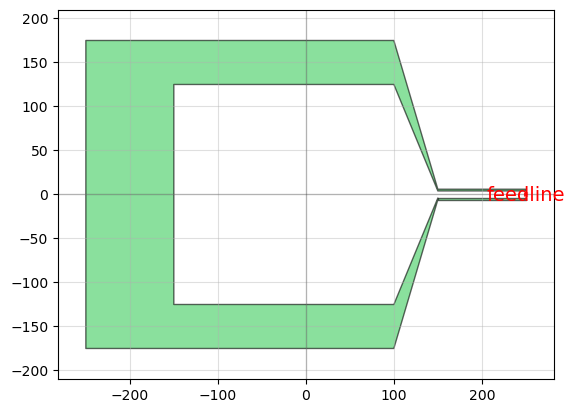

In [4]:
contact = make_feedline_contact(
    pad_size = 250,
    taper_len = 50,
    feedline_len = 100,
    feedline_width = 8,
    ground_gap = 2
)
qp(contact)

c:\Users\emmag\anaconda3\envs\data_analysis\Lib\site-packages\phidl\path.py:300: RuntimeWarning: invalid value encountered in divide
  normals = (normals.T / np.linalg.norm(normals, axis=1)).T
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


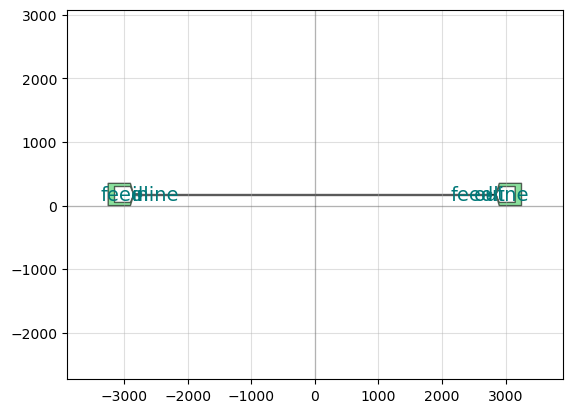

In [5]:
feedline = phidl.Device('feedline')
contact1 = feedline.add_ref(contact)
contact2 = feedline.add_ref(contact)
contact1.x = -3000
contact1.ymin = 0
contact2.rotate(180)
contact2.x = 3000
contact2.ymin = 0

def connect_feedline_to_bondpad(bondpad1,bondpad2,width,gap,init_len=3550):
    connect = phidl.routing.path_U(bondpad1,bondpad2,length1=init_len)
    X = phidl.CrossSection()
    X.add(width = width, ports = ('in','out'))
    P = phidl.path.smooth(connect,radius=250)
    connect = P.extrude(X)
    connect = pg.outline(connect,distance = gap, open_ports=100)
    return connect

line = connect_feedline_to_bondpad(contact1.ports['feedline'],contact2.ports['feedline'],width=8,gap=2)
line_ref = feedline.add_ref(line)
line_ref.connect('in',contact1.ports['feedline'])

qp(feedline)

In [6]:
def calculate_segment_length(
    L_len=400,
    radius=200,
    direction = -1,
    coupling_length = 100,
):
    P = Path()
    P.append(pp.straight(coupling_length))
    direction = 1
    P.append(pp.euler(radius=radius, angle=90*direction,use_eff=True))

    P.append(pp.straight(L_len))
    P.append(pp.euler(radius=radius, angle=-180*direction))
    P.append(pp.straight(L_len))
    direction *= -1
    P.append(pp.straight(radius/4))
    P.append(pp.euler(radius=radius, angle=-90*direction,use_eff=True))
    
    return P.length()

In [7]:
def make_coupling_elbow(
        coupling_length,
        turn_radius = 100,
        space = 100
    ):

    P = Path()
    P.append(pp.straight(coupling_length))
    direction = 1
    P.append(pp.euler(radius=turn_radius, angle=90*direction,use_eff=True))
    # current_length = P.length()
    # remaining_length = total_elbow_length - current_length
    # P.append(pp.straight(remaining_length))
    P.append(pp.straight(space))

    return P

In [8]:
def make_lamda2_res_straight(
    radius=50,
    width=2,
    center_pin_length=3500,
    gap = 60,
    coupling_length = 100,
    space=100
):

    elbow = make_coupling_elbow(coupling_length=coupling_length,turn_radius = radius,space=space)
    P = elbow.append(pp.straight(center_pin_length-elbow.length()))

    print('total length',P.length())

    D = Device('meander')
    X = phidl.CrossSection()
    X.add(width = width, ports = (1,2))

    D << P.extrude(X)
    # D.add_port(D.references[0].ports[2])

    res_outline = pg.outline(D,distance=gap)
    res_outline.xmin = 0

    return res_outline

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


total length 7499.999999999999


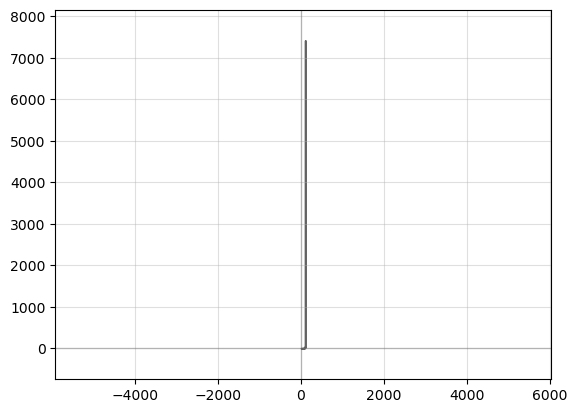

In [9]:
center_pin_width = 8
ground_plane_gap = 2
center_pin_length = 7500
radius = 50
coupling_length = 50

res= make_lamda2_res_straight(center_pin_length=center_pin_length,radius=radius,width=center_pin_width,gap=ground_plane_gap,coupling_length=coupling_length)

qp(res)

In [10]:
def make_lamda2_res_meander(
    L_len=300,
    radius=150,
    width=2,
    center_pin_length=7000,
    gap = 60,
    coupling_length = 100,
    space=100
):

    P = Path()
    direction = -1
    P.append(pp.euler(radius=radius, angle=90 * direction, use_eff=True))
    total_length = P.length()
    add_length = calculate_segment_length(L_len=L_len,radius=radius,coupling_length=coupling_length)
    while total_length < (center_pin_length-add_length-space):
        
        P.append(pp.straight(L_len))
        P.append(pp.euler(radius=radius, angle=-180 * direction))
        P.append(pp.straight(L_len))
        direction *= -1
        P.append(pp.straight(radius/4))
        total_length = P.length()

    P.append(pp.euler(radius=radius, angle=-90 * direction,use_eff=True))
    total_length = P.length()

    elbow = make_coupling_elbow(coupling_length=coupling_length,turn_radius=radius,space=space)
    P = elbow.append(P)

    remaining_len = center_pin_length - P.length()
    if remaining_len < 0:
        print("ERROR! NEGATIVE LENGTH!")

    P.append(pp.straight(remaining_len))

    print(P.length())

    D = Device('meander')
    X = phidl.CrossSection()
    X.add(width = width, ports = (1,2))

    D << P.extrude(X)
    # D.add_port(D.references[0].ports[2])

    res_outline = pg.outline(D,distance=gap)
    res_outline.xmin = 0

    return res_outline

In [11]:
center_pin_width = 8
ground_plane_gap = 2
center_pin_length = 7000
radius = 50
straight = 50

def make_resonators(
        center_pin_lengths = [3500,4000,4500,5000,5500,6000],
        center_pin_width = 8,
        ground_plane_gap = 2,
        radius = 50,
        straight = 250,
        coupling_length = 50,
        space = 200
        ):
        res_dict = {}
        for center_pin_length in center_pin_lengths:
                res= make_lamda2_res_meander(L_len=straight,
                                             center_pin_length=center_pin_length,
                                             radius=radius,
                                             width=center_pin_width,
                                             gap=ground_plane_gap,
                                             coupling_length=coupling_length,
                                             space=space)
                res_dict[center_pin_length] = res
        return res_dict

In [12]:
res_dict = make_resonators(
    center_pin_lengths = [7500,8000,8500,9000,9500,10000],
    center_pin_width = 8,
    ground_plane_gap = 2,
    radius = 50,
    straight = 200,
    coupling_length = 20,
    space=300
)
for len, res in res_dict.items():
    print(len)

7499.999999999999
8000.0
8500.0
9000.0
9500.0
10000.0
7500
8000
8500
9000
9500
10000


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


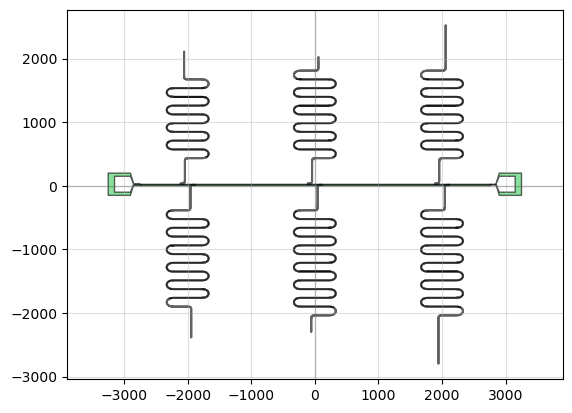

'stemmer_res.gds'

In [13]:
layout = phidl.Device('layout')
feedline_ref = layout.add_ref(feedline)
feedline_ref.ymax = 200

x_idx = 0
y_idx = 0
x_vals = [-2000,0,2000]
for _, res in res_dict.items():
    if y_idx < 3:
        res_ref = layout.add_ref(res)
        res_ref.ymin = 29
        res_ref.x = x_vals[np.mod(x_idx,3)]

    if y_idx >= 3:
        res_ref = layout.add_ref(res)
        res_ref.rotate(180)
        res_ref.ymax = 21
        res_ref.x = x_vals[np.mod(x_idx,3)]

    x_idx += 1
    y_idx += 1

# Alignment markers.
# coord = [1000,1000]
# for xmag in [-1,1,-3,3]:
#     for ymag in [-1,1,-3,3]:
#         xloc = xmag*coord[0]
#         yloc = ymag*coord[1]
#         marker_ref = layout.add_ref(marker)
#         marker_ref.x = xloc
#         marker_ref.y = yloc

qp(layout)
layout.write_gds('stemmer_res.gds')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


total length 7499.999999999999


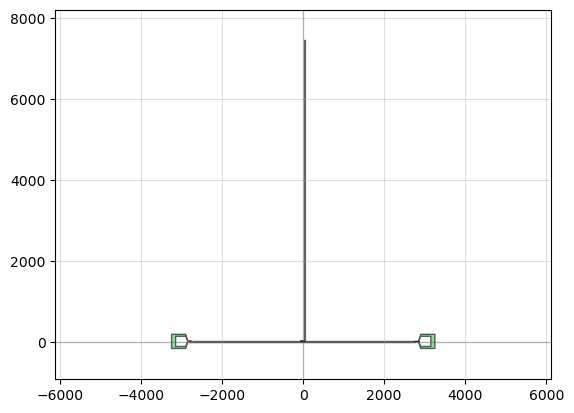

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


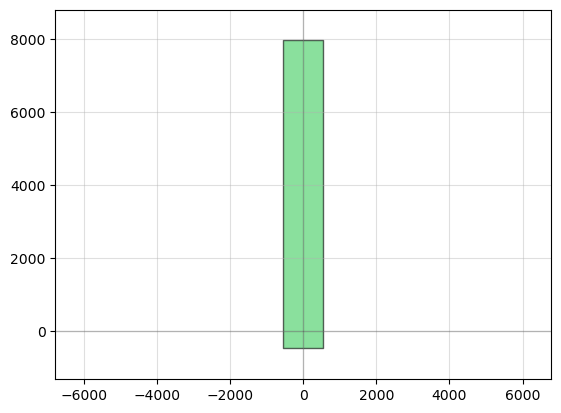

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


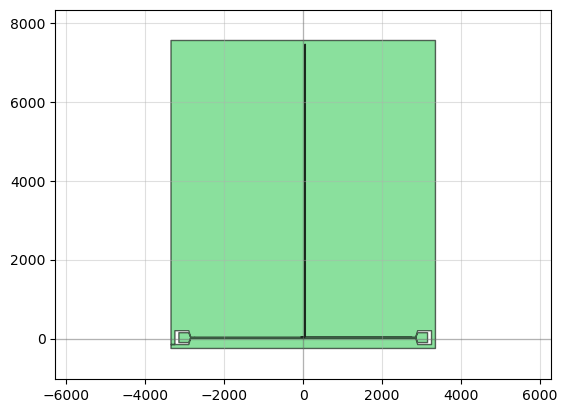

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


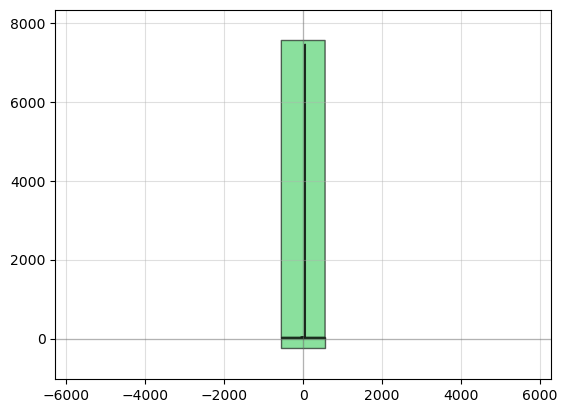

'lambda2_7500um_7.50ghz_50um_coupling.gds'

In [15]:
# Sim layout!
center_pin_width = 8
ground_plane_gap = 2
center_pin_length = 7500
radius = 50
coupling_length = 50

res= make_lamda2_res_straight(center_pin_length=center_pin_length,radius=radius,width=center_pin_width,gap=ground_plane_gap,coupling_length=coupling_length)

layout = phidl.Device('layout')
feedline_ref = layout.add_ref(feedline)
feedline_ref.ymax = 200

res_ref = layout.add_ref(res)
res_ref.ymin = 29
res_ref.x = 0

qp(layout)

b = res_ref.bbox
cutout = pg.outline(pg.bbox(res_ref.bbox),distance = 500)
padding = 500
bbox = [
    [b[0][0] - padding, b[0][1] - padding],  # xmin - pad, ymin - pad
    [b[1][0] + padding, b[1][1] + padding]   # xmax + pad, ymax + pad
]
bbox = pg.bbox(bbox)
qp(bbox)

inverted_layout = pg.invert(layout,border = 100,layer=0)
qp(inverted_layout)

cutout = pg.boolean(bbox,inverted_layout,operation='and')
qp(cutout)
cutout.write_gds('lambda2_7500um_7.50ghz_50um_coupling.gds')